In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from IPython.display import display

In [2]:
wordpress_report    = "Wordpress Summary/IdleTesting/Wordpress Report - Idle Summary.csv"
ghost_report = "Ghost Summary/IdleTesting/Ghost Report - Idle Summary.csv"
drupal_report = "Drupal Summary/IdleTesting/Drupal Report - Idle Summary.csv"

wordpress = pd.read_csv(wordpress_report)
ghost = pd.read_csv(ghost_report)
drupal = pd.read_csv(drupal_report)

In [3]:
wordpress_avg = wordpress.iloc[-1:].copy()
ghost_avg = ghost.iloc[-1:].copy()
drupal_avg = drupal.iloc[-1:].copy()

wordpress_avg['website'] = 'WordPress'
ghost_avg['website'] = 'Ghost'
drupal_avg['website'] = 'Drupal'

comparison = pd.concat([wordpress_avg, ghost_avg, drupal_avg], ignore_index=True)

In [4]:
cols = ['website', 'avg_response (ms)', 'p95_response (ms)',  'avg_latency (ms)',
        'error_rate (%)', 'throughput (req/s)', 'apdex']

result = comparison[cols].round(3)
result.to_csv("Assets Testing/Idle/Comparison Report - Idle.csv", index=False)

styled = (result.style
          .hide(axis="index")
          .format(precision=3)
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
          ]))

display(styled)

website,avg_response (ms),p95_response (ms),avg_latency (ms),error_rate (%),throughput (req/s),apdex
WordPress,216.316,342.810,150.734,0.008,12.888,0.989
Ghost,98.248,144.000,89.096,0.002,28.762,1.000
Drupal,94.744,160.600,82.668,0.006,29.980,1.000


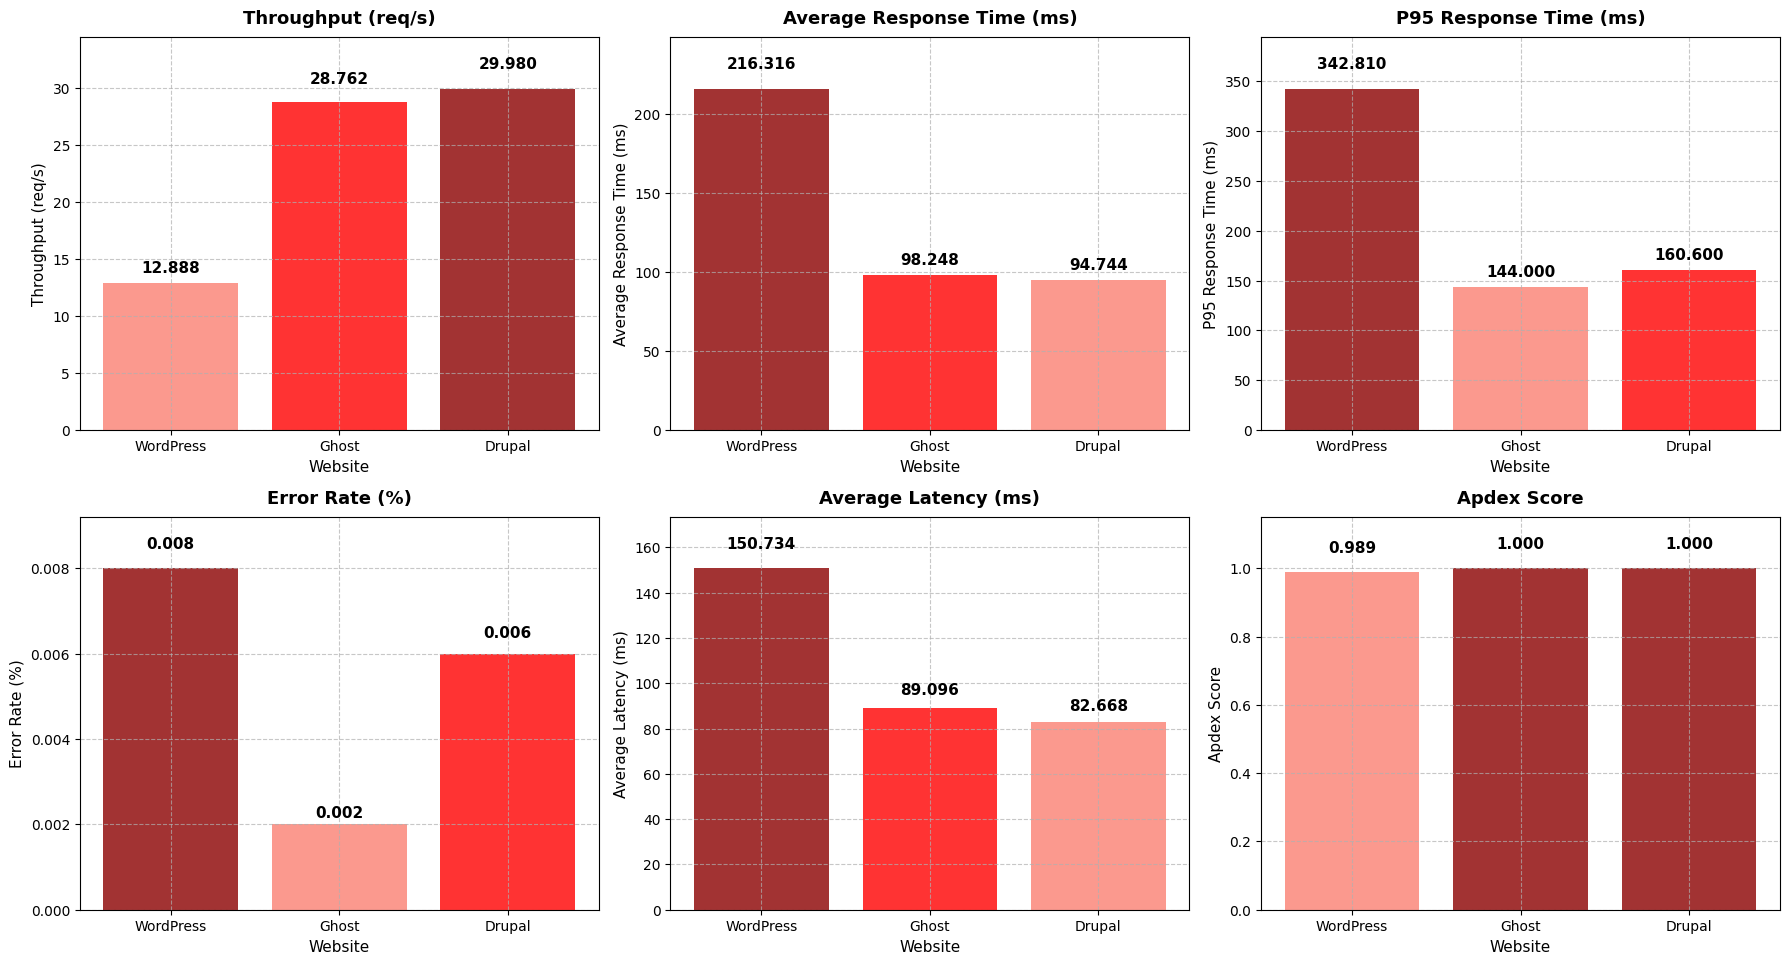

In [5]:
fig, axs = plt.subplots(3, 3, figsize=(18, 15))

metrics = [
    ('throughput (req/s)', 'Throughput (req/s)'         ),
    ('avg_response (ms)',  'Average Response Time (ms)' ),
    ('p95_response (ms)',  'P95 Response Time (ms)'     ),
    ('error_rate (%)',     'Error Rate (%)'             ),
    ('avg_latency (ms)',   'Average Latency (ms)'       ),
    ('apdex',              'Apdex Score'                ),
]

for i, (col, title) in enumerate(metrics):
    row, col_idx = divmod(i, 3)

    values = result[col]
    uniques = sorted(values.unique())
    
    def color_map(v):
        if len(uniques) == 1:
            return 'red'
        elif len(uniques) == 2:
            return 'salmon' if v == uniques[0] else 'darkred'
        else:
            if v == uniques[0]:
                return 'salmon'
            elif v == uniques[-1]:
                return 'darkred'
            else:
                return 'red'
    
    colors = [color_map(v) for v in values]

    bars = axs[row, col_idx].bar(result['website'], result[col], color=colors, alpha=0.8)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Website", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)

    max_val = result[col].max()
    axs[row, col_idx].set_ylim(0, max_val * 1.15)
    
    for bar in bars:
        height = bar.get_height()
        axs[row, col_idx].text(bar.get_x() + bar.get_width()/2, height * 1.05, 
                               f'{height:.3f}', ha='center', va='bottom', 
                               fontsize=11, fontweight='bold')

for j in range(6, 9):
    axs.flat[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig("Assets Testing/Idle/Comparison Report - Idle.png")
plt.show()

In [6]:
wordpress_result    = "Wordpress Summary/IdleTesting/Wordpress Result - Idle Summary.csv"
ghost_result = "Ghost Summary/IdleTesting/Ghost Result - Idle Summary.csv"
drupal_result = "Drupal Summary/IdleTesting/Drupal Result - Idle Summary.csv"

wordpress_monitor = pd.read_csv(wordpress_result)
ghost_monitor = pd.read_csv(ghost_result)
drupal_monitor = pd.read_csv(drupal_result)

In [7]:
wordpress_monitoring = wordpress_monitor.iloc[-1:].copy()
ghost_monitoring = ghost_monitor.iloc[-1:].copy()
drupal_monitoring = drupal_monitor.iloc[-1:].copy()

wordpress_monitoring['Website'] = 'WordPress'
ghost_monitoring['Website'] = 'Ghost'
drupal_monitoring['Website'] = 'Drupal'

comparison = pd.concat([wordpress_monitoring, ghost_monitoring, drupal_monitoring], ignore_index=True)

In [8]:
cols_monitoring = ['Website', 'Avg CPU (m)', 'Max CPU (m)', 
        'Avg Memory (Mi)', 'Max Memory (Mi)']

result_monitoring = comparison[cols_monitoring].round(3)
result_monitoring.to_csv("Assets Testing/Idle/Comparison Result - Idle.csv", index=False)

styled = (result_monitoring.style
          .hide(axis="index")
          .format(precision=3)
          .set_table_styles([
              {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
          ]))

display(styled)

Website,Avg CPU (m),Max CPU (m),Avg Memory (Mi),Max Memory (Mi)
WordPress,167.198,542.600,243.718,458.400
Ghost,166.784,427.800,288.926,428.800
Drupal,77.408,158.000,310.376,434.800


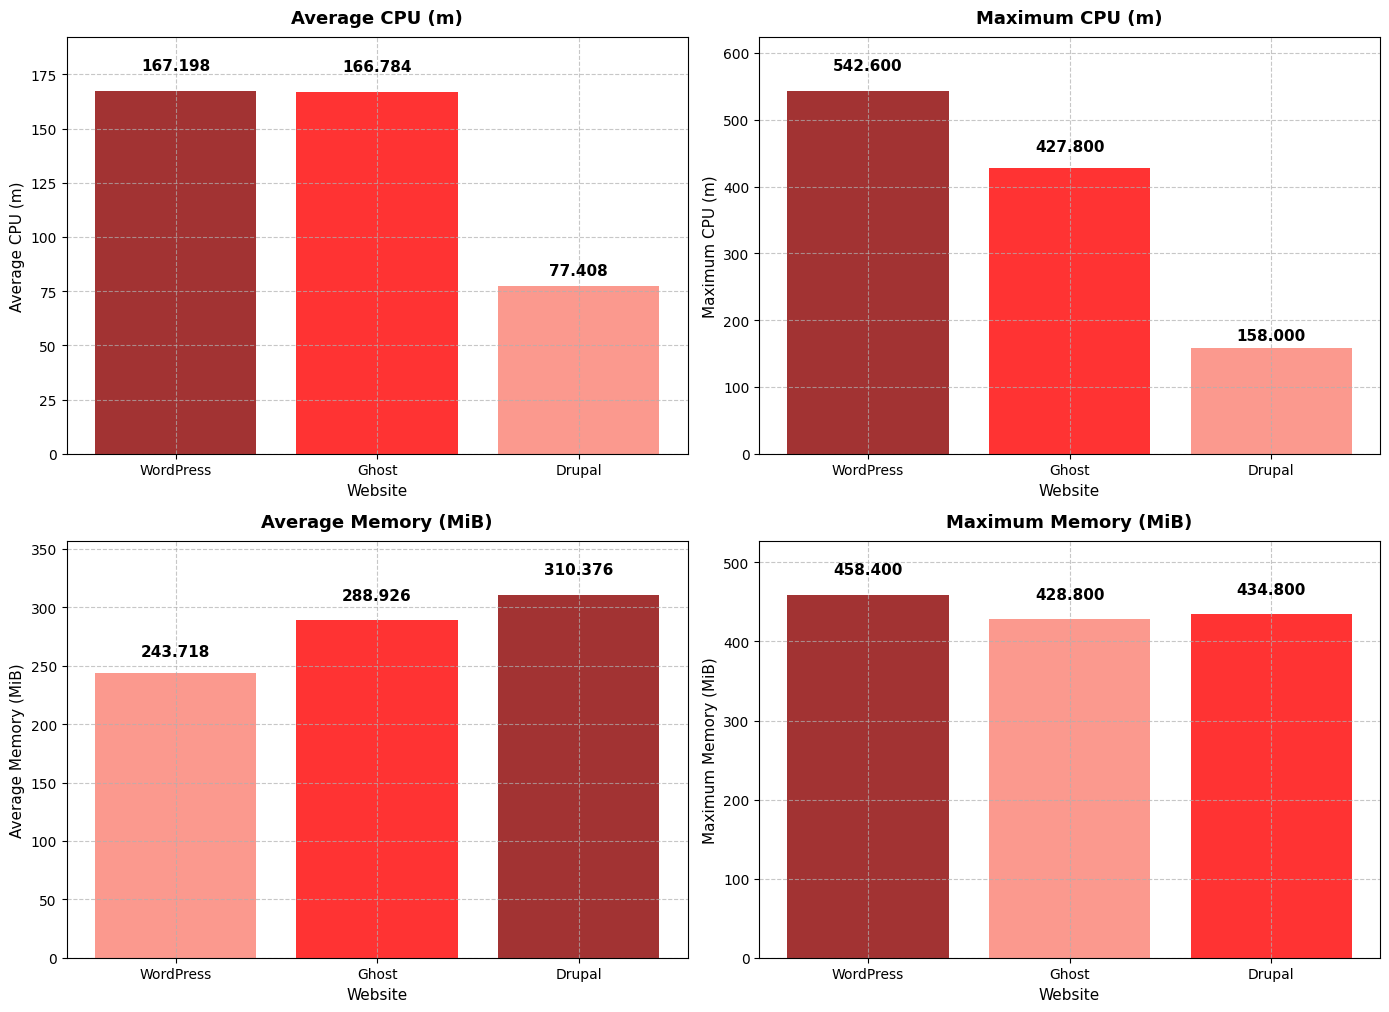

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(14, 11))

metrics = [
    ('Avg CPU (m)',             'Average CPU (m)'              ),
    ('Max CPU (m)',             'Maximum CPU (m)'              ),
    ('Avg Memory (Mi)',         'Average Memory (MiB)'         ),
    ('Max Memory (Mi)',         'Maximum Memory (MiB)'         ),
]

for i, (col, title) in enumerate(metrics):
    row, col_idx = divmod(i, 2)

    values = result_monitoring[col]
    uniques = sorted(values.unique())
    
    def color_map(v):
        if len(uniques) == 1:
            return 'red'
        elif len(uniques) == 2:
            return 'salmon' if v == uniques[0] else 'darkred'
        else:
            if v == uniques[0]:
                return 'salmon'
            elif v == uniques[-1]:
                return 'darkred'
            else:
                return 'red'
    
    colors = [color_map(v) for v in values]
    
    bars = axs[row, col_idx].bar(result_monitoring['Website'], result_monitoring[col], color=colors, alpha=0.8)
    
    axs[row, col_idx].set_title(title, fontsize=13, fontweight='bold', pad=10)
    axs[row, col_idx].set_xlabel("Website", fontsize=11)
    axs[row, col_idx].set_ylabel(title, fontsize=11)
    axs[row, col_idx].grid(True, linestyle='--', alpha=0.7)

    max_val = result_monitoring[col].max()
    axs[row, col_idx].set_ylim(0, max_val * 1.15)
    
    for bar in bars:
        height = bar.get_height()
        axs[row, col_idx].text(bar.get_x() + bar.get_width()/2, height * 1.05, 
                               f'{height:.3f}', ha='center', va='bottom', 
                               fontsize=11, fontweight='bold')


plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("Assets Testing/Idle/Comparison Result - Idle.png")
plt.show()